<a href="https://colab.research.google.com/github/zyan-007/learning-stash-code/blob/main/neurons_and_layers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras import Sequential
from tensorflow.keras.losses import MeanSquaredError, BinaryCrossentropy
from tensorflow.keras.activations import sigmoid

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)


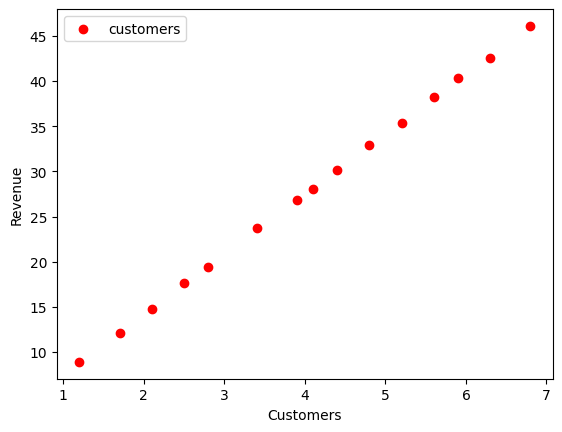

In [9]:
x_train = np.array([1.2, 2.8, 4.1, 3.4, 5.6, 2.1, 6.3, 4.8, 1.7, 5.2, 3.9, 6.8, 2.5, 4.4, 5.9]).reshape(-1, 1)
y_train = np.array([8.9, 19.4, 28.1, 23.7, 38.2, 14.8, 42.6, 32.9, 12.1, 35.4, 26.8, 46.1, 17.6, 30.2, 40.3])

plt.scatter(x_train, y_train, marker="o", color="r", label="customers")
plt.xlabel("Customers")
plt.ylabel("Revenue")
plt.legend();
plt.show()

In [10]:
linear_layer = Dense(units = 1, activation='linear')

In [13]:
linear_layer.get_weights()

[]

In [16]:
a1 = linear_layer(x_train)
w, b = linear_layer.get_weights()
print(f"w: {w}, b: {b}")

w: [[1.6758841]], b: [0.]


In [17]:
set_w = np.array([[6.8]])
set_b = np.array([1.0])

linear_layer.set_weights([set_w, set_b])
print(linear_layer.get_weights())

[array([[6.8]], dtype=float32), array([1.], dtype=float32)]


In [19]:
tf_predict = linear_layer(x_train)
np_predict = (x_train @ set_w) + set_b

print(f"tf_predict: {tf_predict}")
print(f"np_predict: {np_predict}")

tf_predict: [[ 9.160001]
 [20.04    ]
 [28.880001]
 [24.12    ]
 [39.08    ]
 [15.28    ]
 [43.840004]
 [33.640003]
 [12.56    ]
 [36.36    ]
 [27.52    ]
 [47.24    ]
 [18.      ]
 [30.920002]
 [41.120003]]
np_predict: [[ 9.16]
 [20.04]
 [28.88]
 [24.12]
 [39.08]
 [15.28]
 [43.84]
 [33.64]
 [12.56]
 [36.36]
 [27.52]
 [47.24]
 [18.  ]
 [30.92]
 [41.12]]


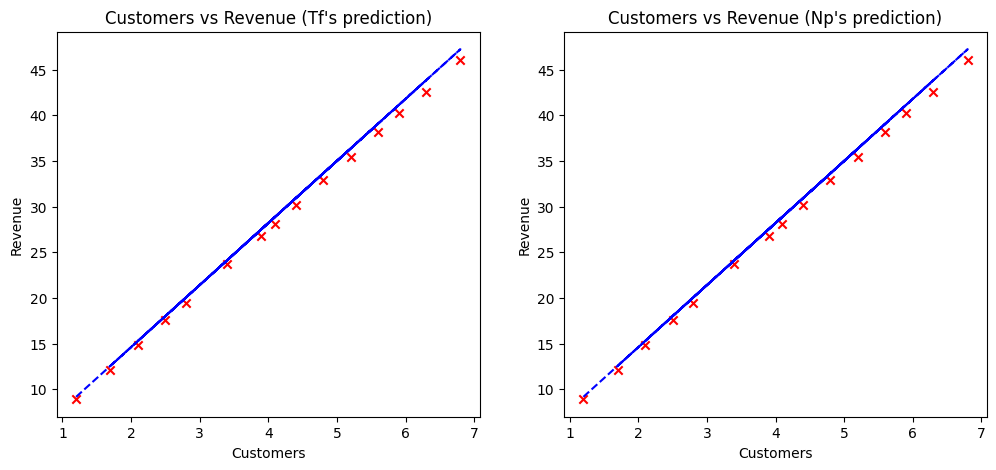

In [39]:
fig, ax=  plt.subplots(1, 2, figsize=(12,5))

ax[0].set_xlabel("Customers")
ax[0].set_ylabel("Revenue")
ax[0].set_title("Customers vs Revenue (Tf's prediction)")
ax[0].scatter(x_train, y_train, marker="x", color="r")
ax[0].plot(x_train, tf_predict, color = 'b', linestyle='dashed')

ax[1].set_xlabel("Customers")
ax[1].set_ylabel("Revenue")
ax[1].set_title("Customers vs Revenue (Np's prediction)")
ax[1].scatter(x_train, y_train, marker="x", color="r")
ax[1].plot(x_train, np_predict, color = 'b', linestyle='dashed')

plt.show()


In [40]:
x_train = np.array([12.4, 18.9, 25.3, 31.7, 38.2, 44.6, 51.1, 57.5, 64.0, 70.4, 76.9, 83.3]).reshape(-1, 1)
y_train = np.array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1])

x_train, y_train

(array([[12.4],
        [18.9],
        [25.3],
        [31.7],
        [38.2],
        [44.6],
        [51.1],
        [57.5],
        [64. ],
        [70.4],
        [76.9],
        [83.3]]),
 array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1]))

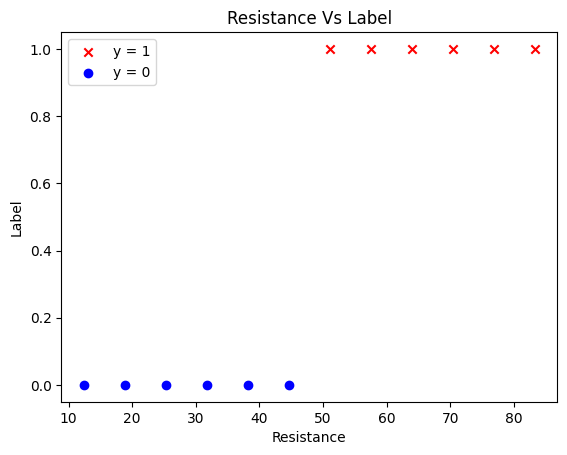

In [53]:
pos = y_train == 1
neg = y_train == 0
# print(pos, neg)

plt.scatter(x_train[pos], y_train[pos], marker="x", color="r", label="y = 1")
plt.scatter(x_train[neg], y_train[neg], marker="o", color="b", label="y = 0")
plt.xlabel("Resistance")
plt.ylabel("Label")
plt.title("Resistance Vs Label")
plt.legend()
plt.show()

In [43]:
model = Sequential(
    [   Input(shape=(1,)),
        Dense(1, activation='sigmoid', name='L1')]
)

In [44]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ L1 (Dense)                      │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [49]:
logistic_layer = model.get_layer('L1')
w, b = logistic_layer.get_weights()

print(f"w: {w}, b: {b}")

w: [[-0.6589918]], b: [0.]


In [55]:
W = np.array([[0.18]])
b = np.array([-8.6])

logistic_layer.set_weights([W, b])
w, b = logistic_layer.get_weights()

print(f"w: {w}, b: {b}")

w: [[0.18]], b: [-8.6]


In [64]:
tf_predict = (model.predict(x_train) >= 0.5).astype(int)
np_predict = ((sigmoid(x_train @ W + b) >= 0.5).numpy()).astype(int)
print(tf_predict, end = "\n\n")
print(np_predict)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
[[0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]]

[[0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]]


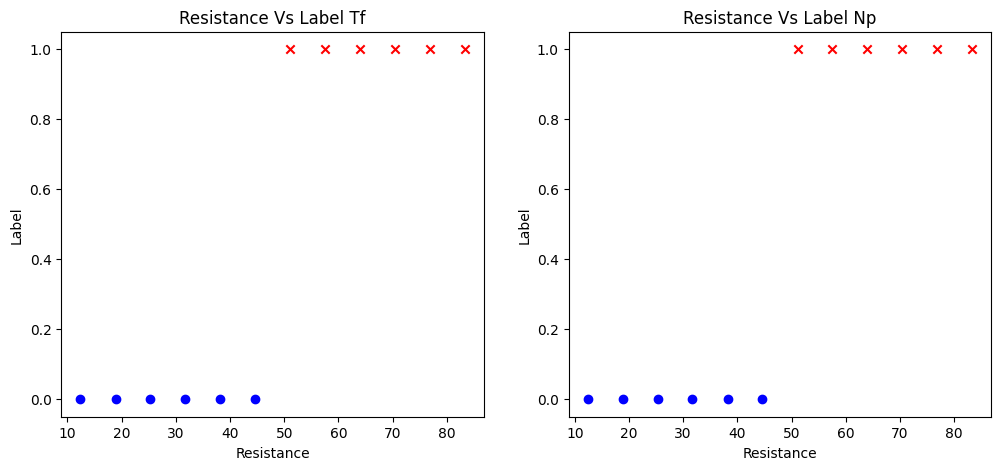

In [65]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(x_train[pos], tf_predict[pos], marker="x", color = "r")
ax[0].scatter(x_train[neg], tf_predict[neg], marker="o", color="b")
ax[0].set_xlabel("Resistance")
ax[0].set_ylabel("Label")
ax[0].set_title("Resistance Vs Label Tf")

ax[1].scatter(x_train[pos], np_predict[pos], marker="x", color = "r")
ax[1].scatter(x_train[neg], np_predict[neg], marker="o", color="b")
ax[1].set_xlabel("Resistance")
ax[1].set_ylabel("Label")
ax[1].set_title("Resistance Vs Label Np")

plt.show()